Ячейка 1/8: Импорты, Seed, Device


In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from torchvision.utils import draw_bounding_boxes
from torchvision.ops import box_iou
import warnings
warnings.filterwarnings('ignore')

# Настройки
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"{'='*60}")
print(f"DEVICE CONFIGURATION")
print(f"{'='*60}")
print(f"Using device: {DEVICE}")

if DEVICE.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("⚠️ WARNING: CUDA not available!")

print(f"{'='*60}")

# Фиксация случайности
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Папки
os.makedirs("artifacts/figures", exist_ok=True)
print("Artifacts directory created.")

# Batch size для GPU Colab
BATCH_SIZE = 64

DEVICE CONFIGURATION
Using device: cuda
GPU Name: Tesla T4
CUDA Version: 12.8
Artifacts directory created.


Ячейка 2/8: Данные (SVHN) + DataLoader

In [2]:
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Загрузка SVHN
train_full = datasets.SVHN(root="./data", split="train", download=True, transform=None)
test_full = datasets.SVHN(root="./data", split="test", download=True, transform=None)

# Split train -> train (80%) + val (20%)
n_train = int(len(train_full) * 0.8)
indices = torch.randperm(len(train_full)).tolist()
train_idx, val_idx = indices[:n_train], indices[n_train:]

class SVHN_Dual(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        img, label = self.base[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset_base = SVHN_Dual(train_full, train_idx, transform_base)
val_dataset = SVHN_Dual(train_full, val_idx, transform_base)
train_dataset_aug = SVHN_Dual(train_full, train_idx, transform_aug)
test_dataset = SVHN_Dual(test_full, list(range(len(test_full))), transform_base)

# DataLoader
loader_train_base = DataLoader(train_dataset_base, batch_size=BATCH_SIZE, shuffle=True)
loader_train_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
loader_val = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
loader_test = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset_base)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Sanity check
x, y = next(iter(loader_train_base))
print(f"Batch shape: x={x.shape}, y={y.shape}")

Train: 58605, Val: 14652, Test: 26032
Batch shape: x=torch.Size([64, 3, 32, 32]), y=torch.Size([64])


Ячейка 3/8: Модели и функции

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 64), nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

Ячейка 4/8: Эксперименты C1-C4

In [4]:
results = []
best_model_state = None
best_val_acc = 0
best_config = {}
best_history = None
best_model_class = None

experiments = [
    {"id": "C1", "model_class": SimpleCNN, "loader": loader_train_base, "name": "CNN-Base", "aug": False},
    {"id": "C2", "model_class": SimpleCNN, "loader": loader_train_aug, "name": "CNN-Aug", "aug": True},
    {"id": "C3", "model_class": "resnet18", "loader": loader_train_base, "name": "ResNet-Freeze", "freeze": True},
    {"id": "C4", "model_class": "resnet18", "loader": loader_train_base, "name": "ResNet-FineTune", "freeze": False},
]

EPOCHS = 15
criterion = nn.CrossEntropyLoss()

for exp in experiments:
    print(f"\n{'='*50}")
    print(f"Running {exp['id']} ({exp['name']})...")
    print(f"{'='*50}")

    # Создание модели
    if exp["model_class"] == SimpleCNN:
        model = SimpleCNN(num_classes=10).to(DEVICE)
    else:
        # Загружаем pretrained ResNet18
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Заменяем последний слой под 10 классов
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, 10)

        # 👉 ВАЖНО: Перемещаем модель на устройство ПОСЛЕ модификации слоёв
        model = model.to(DEVICE)

        # Настройка requires_grad
        if exp.get("freeze"):
            # Замораживаем весь backbone, обучаем только fc
            for param in model.parameters():
                param.requires_grad = False
            for param in model.fc.parameters():
                param.requires_grad = True
        else:
            # Fine-tune: размораживаем layer4 + fc
            for param in model.parameters():
                param.requires_grad = False
            for name, param in model.named_parameters():
                if 'layer4' in name or 'fc' in name:
                    param.requires_grad = True

    # Проверка что всё на одном устройстве
    print(f"  Model device: {next(model.parameters()).device}")

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(EPOCHS):
        t_loss, t_acc = train_epoch(model, exp["loader"], optimizer, criterion, DEVICE)
        v_loss, v_acc = evaluate(model, loader_val, criterion, DEVICE)
        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["val_acc"].append(v_acc)
        print(f"Epoch {epoch+1}/{EPOCHS}: Val Acc={v_acc:.4f}")

    # Сохранение лучшей модели
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        # Сохраняем state_dict на CPU для совместимости
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_config = {"id": exp["id"], "name": exp["name"], "epochs": EPOCHS}
        best_history = history.copy()
        best_model_class = exp["model_class"]
        print(f"  → New best! Val Acc: {v_acc:.4f}")

    results.append({
        "experiment_id": exp["id"], "task": "classification", "dataset": "SVHN",
        "seed": SEED, "model_summary": exp["name"], "optimizer": "Adam", "lr": 0.001,
        "epochs_trained": EPOCHS, "best_val_accuracy": round(max(history["val_acc"]), 4),
        "test_accuracy": "", "precision": "", "recall": "", "mean_iou": "",
        "notes": f"aug={exp.get('aug', 'N/A')}"
    })

print(f"\n{'='*50}")
print(f"Best model: {best_config['name']} with Val Acc: {best_val_acc:.4f}")
print(f"{'='*50}")


Running C1 (CNN-Base)...
  Model device: cuda:0
Epoch 1/15: Val Acc=0.8342
Epoch 2/15: Val Acc=0.8493
Epoch 3/15: Val Acc=0.8673
Epoch 4/15: Val Acc=0.8719
Epoch 5/15: Val Acc=0.8722
Epoch 6/15: Val Acc=0.8749
Epoch 7/15: Val Acc=0.8784
Epoch 8/15: Val Acc=0.8797
Epoch 9/15: Val Acc=0.8822
Epoch 10/15: Val Acc=0.8797
Epoch 11/15: Val Acc=0.8798
Epoch 12/15: Val Acc=0.8816
Epoch 13/15: Val Acc=0.8780
Epoch 14/15: Val Acc=0.8801
Epoch 15/15: Val Acc=0.8799
  → New best! Val Acc: 0.8799

Running C2 (CNN-Aug)...
  Model device: cuda:0
Epoch 1/15: Val Acc=0.7243
Epoch 2/15: Val Acc=0.7703
Epoch 3/15: Val Acc=0.8041
Epoch 4/15: Val Acc=0.8145
Epoch 5/15: Val Acc=0.8187
Epoch 6/15: Val Acc=0.8267
Epoch 7/15: Val Acc=0.8354
Epoch 8/15: Val Acc=0.8374
Epoch 9/15: Val Acc=0.8374
Epoch 10/15: Val Acc=0.8410
Epoch 11/15: Val Acc=0.8478
Epoch 12/15: Val Acc=0.8449
Epoch 13/15: Val Acc=0.8520
Epoch 14/15: Val Acc=0.8554
Epoch 15/15: Val Acc=0.8529

Running C3 (ResNet-Freeze)...
  Model device: cuda

Ячейка 5/8: Сохранение лучшей модели

In [5]:
print("\nEvaluating Best Model on Test...")

if best_model_class == SimpleCNN:
    final_model = SimpleCNN(num_classes=10).to(DEVICE)
else:
    final_model = models.resnet18(weights=None).to(DEVICE)
    final_model.fc = nn.Linear(512, 10)

final_model.load_state_dict(best_model_state)
_, test_acc = evaluate(final_model, loader_test, criterion, DEVICE)
print(f"Test Accuracy: {test_acc:.4f}")

for r in results:
    if r["experiment_id"] == best_config["id"]:
        r["test_accuracy"] = round(test_acc, 4)

torch.save(best_model_state, "artifacts/best_classifier.pt")
with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(best_config, f, indent=2)

print("Saved: artifacts/best_classifier.pt")
print("Saved: artifacts/best_classifier_config.json")


Evaluating Best Model on Test...
Test Accuracy: 0.8675
Saved: artifacts/best_classifier.pt
Saved: artifacts/best_classifier_config.json


Ячейка 6/8: Графики Часть A

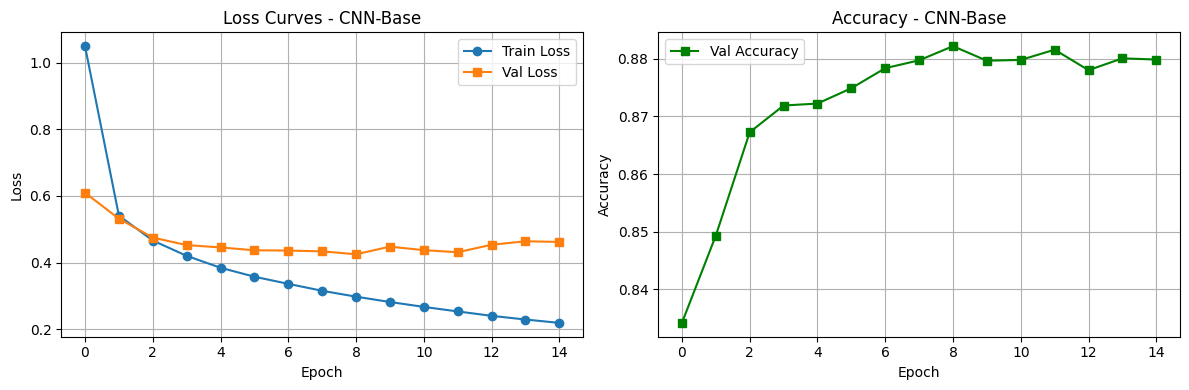

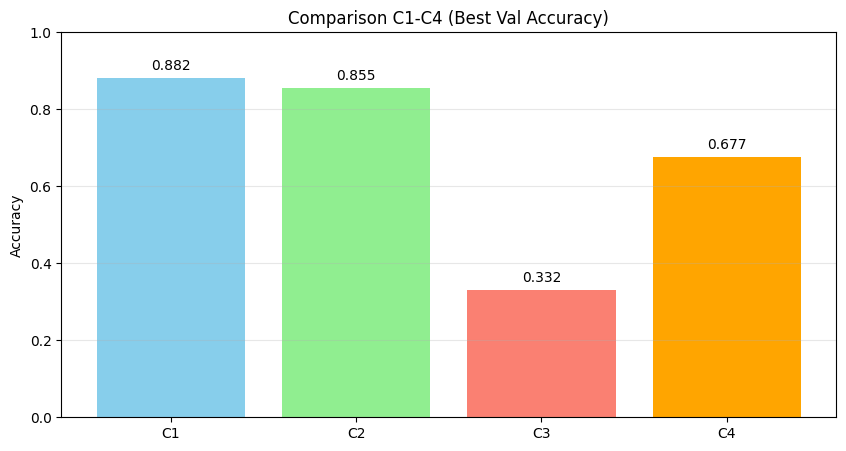

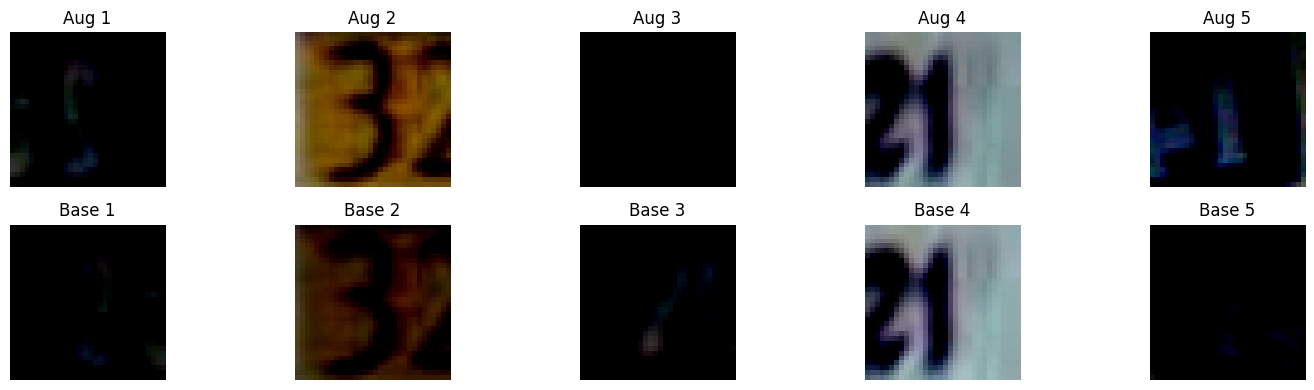

In [6]:
if best_history:
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(best_history["train_loss"], label="Train Loss", marker='o')
    plt.plot(best_history["val_loss"], label="Val Loss", marker='s')
    plt.title(f"Loss Curves - {best_config['name']}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(best_history["val_acc"], label="Val Accuracy", marker='s', color='green')
    plt.title(f"Accuracy - {best_config['name']}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("artifacts/figures/classification_curves_best.png", dpi=150)
    plt.show()

ids = [r["experiment_id"] for r in results if r["task"] == "classification"]
accs = [r["best_val_accuracy"] for r in results if r["task"] == "classification"]
colors = ['skyblue', 'lightgreen', 'salmon', 'orange']

plt.figure(figsize=(10, 5))
plt.bar(ids, accs, color=colors)
plt.title("Comparison C1-C4 (Best Val Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
for i, v in enumerate(accs):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.grid(axis='y', alpha=0.3)
plt.savefig("artifacts/figures/classification_compare.png", dpi=150)
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(15, 4))
for i in range(5):
    img, label = train_dataset_aug[i]
    axes[0, i].imshow(img.permute(1, 2, 0))
    axes[0, i].set_title(f"Aug {i+1}")
    axes[0, i].axis('off')
    img_base, _ = train_dataset_base[i]
    axes[1, i].imshow(img_base.permute(1, 2, 0))
    axes[1, i].set_title(f"Base {i+1}")
    axes[1, i].axis('off')
plt.tight_layout()
plt.savefig("artifacts/figures/augmentations_preview.png", dpi=150)
plt.show()

Ячейка 7/8: Часть B (Detection VOC)

In [10]:
print("\n" + "="*50)
print("PART B: Detection")
print("="*50)

# Загрузка модели детекции
det_model = models.detection.fasterrcnn_resnet50_fpn(
    weights=models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
)
det_model.eval().to(DEVICE)
print("FasterRCNN loaded.")

# Датасет VOC
voc_dataset = datasets.VOCDetection(
    root="./data_voc",
    year="2012",
    image_set="val",
    download=True
)

# Классы VOC (20 классов + background)
VOC_CLASSES = [
    '__background__', 'aeroplane', 'bicycle', 'bird', 'boat',
    'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable',
    'dog', 'horse', 'motorbike', 'person', 'pottedplant',
    'sheep', 'sofa', 'train', 'tvmonitor'
]
CLASS_MAP = VOC_CLASSES

# 👉 ВАЖНО: Функция для парсинга XML аннотаций VOC
def parse_voc_annotation(target):
    """Извлекает boxes и labels из XML аннотации VOCDetection"""
    boxes = []
    labels = []

    objects = target['annotation']['object']
    # objects может быть списком или одним объектом
    if not isinstance(objects, list):
        objects = [objects]

    for obj in objects:
        bbox = obj['bndbox']
        # VOC формат: [xmin, ymin, xmax, ymax]
        box = [
            float(bbox['xmin']),
            float(bbox['ymin']),
            float(bbox['xmax']),
            float(bbox['ymax'])
        ]
        boxes.append(box)

        # Получаем индекс класса
        class_name = obj['name']
        if class_name in CLASS_MAP:
            labels.append(CLASS_MAP.index(class_name))
        else:
            labels.append(0)  # background

    if len(boxes) > 0:
        return torch.as_tensor(boxes, dtype=torch.float32), torch.as_tensor(labels, dtype=torch.int64)
    else:
        return torch.zeros((0, 4), dtype=torch.float32), torch.zeros((0,), dtype=torch.int64)

# Берём первые 20 изображений для метрик (быстрее)
indices = list(range(min(20, len(voc_dataset))))
voc_subset = Subset(voc_dataset, indices)

def voc_collate(batch):
    return tuple(zip(*batch))

loader_voc = DataLoader(voc_subset, batch_size=1, collate_fn=voc_collate)
print(f"VOC samples: {len(voc_subset)}")

# Функция IoU
def calculate_iou(box1, box2):
    b1 = torch.tensor(box1).float().unsqueeze(0)
    b2 = torch.tensor(box2).float().unsqueeze(0)
    return box_iou(b1, b2).item()

# Метрики
metrics_v1 = {"tp": 0, "fp": 0, "fn": 0, "iou_sum": 0}
metrics_v2 = {"tp": 0, "fp": 0, "fn": 0, "iou_sum": 0}
THRESH_V1, THRESH_V2 = 0.3, 0.7
IOU_THRESH = 0.5

print("\nRunning Detection Inference...")
for idx, (img, target) in enumerate(loader_voc):
    img_tensor = transforms.ToTensor()(img[0]).to(DEVICE)

    # 👉 ВАЖНО: Парсим XML аннотацию для получения GT боксов
    gt_boxes_tensor, gt_labels = parse_voc_annotation(target[0])
    gt_boxes = gt_boxes_tensor.tolist() if len(gt_boxes_tensor) > 0 else []

    with torch.no_grad():
        pred = det_model([img_tensor])[0]

    scores = pred["scores"].cpu().numpy()
    pred_boxes = pred["boxes"].cpu().tolist()

    for thresh, metrics in [(THRESH_V1, metrics_v1), (THRESH_V2, metrics_v2)]:
        kept_boxes = [b for i, b in enumerate(pred_boxes) if scores[i] > thresh]
        matched_gt = [False] * len(gt_boxes)

        for pb in kept_boxes:
            if len(gt_boxes) == 0:
                metrics["fp"] += 1
                continue
            ious = [calculate_iou(pb, gb) for gb in gt_boxes]
            if ious and max(ious) >= IOU_THRESH:
                metrics["tp"] += 1
                metrics["iou_sum"] += max(ious)
                matched_gt[ious.index(max(ious))] = True
            else:
                metrics["fp"] += 1

        metrics["fn"] += matched_gt.count(False)

    if (idx + 1) % 5 == 0:
        print(f"  Processed {idx + 1}/{len(loader_voc)} images")

# Расчет метрик
def calc_metrics(m):
    prec = m["tp"] / (m["tp"] + m["fp"]) if (m["tp"] + m["fp"]) > 0 else 0
    rec = m["tp"] / (m["tp"] + m["fn"]) if (m["tp"] + m["fn"]) > 0 else 0
    miou = m["iou_sum"] / m["tp"] if m["tp"] > 0 else 0
    return prec, rec, miou

p1, r1, i1 = calc_metrics(metrics_v1)
p2, r2, i2 = calc_metrics(metrics_v2)

print(f"\nV1 (thresh=0.3): P={p1:.4f}, R={r1:.4f}, IoU={i1:.4f}")
print(f"V2 (thresh=0.7): P={p2:.4f}, R={r2:.4f}, IoU={i2:.4f}")

# Добавим в results
results.append({
    "experiment_id": "V1", "task": "detection", "dataset": "VOC2012", "seed": SEED,
    "model_summary": "FasterRCNN_ResNet50", "optimizer": "", "lr": "", "epochs_trained": 0,
    "best_val_accuracy": "", "test_accuracy": "",
    "precision": round(p1, 4), "recall": round(r1, 4), "mean_iou": round(i1, 4),
    "notes": f"thresh={THRESH_V1}"
})
results.append({
    "experiment_id": "V2", "task": "detection", "dataset": "VOC2012", "seed": SEED,
    "model_summary": "FasterRCNN_ResNet50", "optimizer": "", "lr": "", "epochs_trained": 0,
    "best_val_accuracy": "", "test_accuracy": "",
    "precision": round(p2, 4), "recall": round(r2, 4), "mean_iou": round(i2, 4),
    "notes": f"thresh={THRESH_V2}"
})


PART B: Detection
FasterRCNN loaded.
VOC samples: 20

Running Detection Inference...
  Processed 5/20 images
  Processed 10/20 images
  Processed 15/20 images
  Processed 20/20 images

V1 (thresh=0.3): P=0.3590, R=0.9655, IoU=0.7571
V2 (thresh=0.7): P=0.5882, R=0.8333, IoU=0.7985


Ячейка 8/8: Визуализация и Сохранение

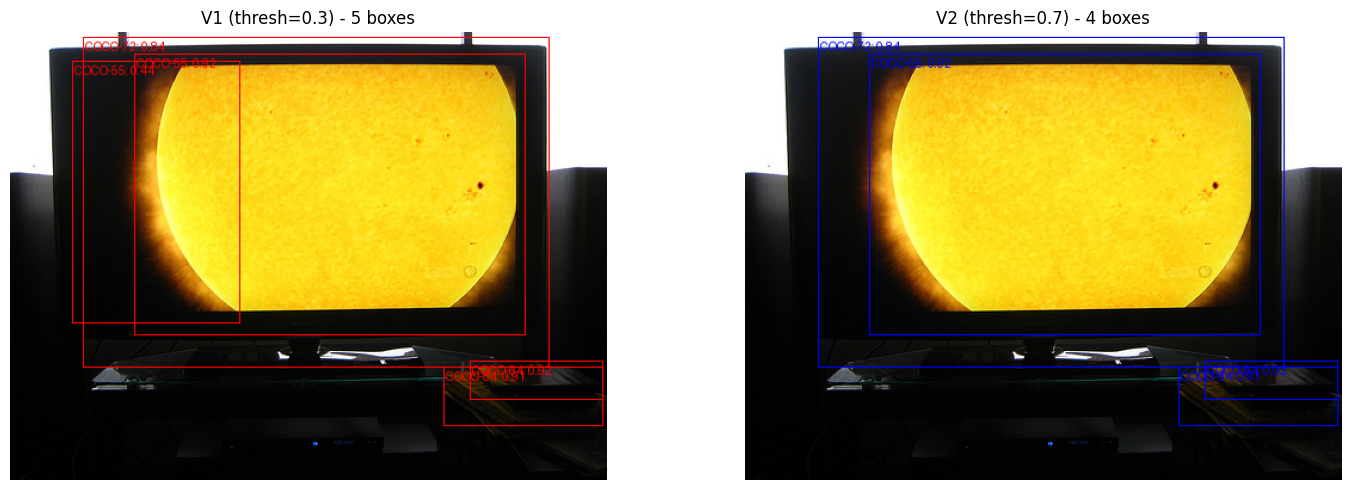

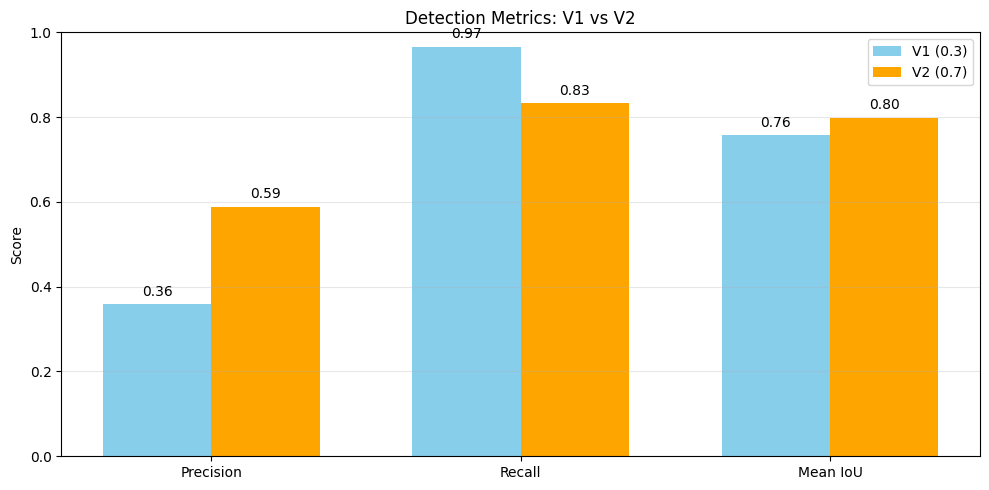


Saved: artifacts/runs.csv

ALL ARTIFACTS SAVED SUCCESSFULLY!

Generated artifacts:
  artifacts/best_classifier_config.json
  artifacts/runs.csv
  artifacts/best_classifier.pt
  artifacts/figures/augmentations_preview.png
  artifacts/figures/classification_compare.png
  artifacts/figures/detection_metrics.png
  artifacts/figures/classification_curves_best.png
  artifacts/figures/detection_examples.png


In [12]:
# Визуализация примеров детекции
img, target = voc_dataset[0]
img_t = transforms.ToTensor()(img).to(DEVICE)

with torch.no_grad():
    pred = det_model([img_t])[0]

# 👉 ВАЖНО: FasterRCNN обучена на COCO, не на VOC!
# Labels модели — это COCO классы (1-90), не VOC (0-20)
# Поэтому не используем CLASS_MAP для labels модели

# Фильтруем по threshold
mask_v1 = pred["scores"] > THRESH_V1
mask_v2 = pred["scores"] > THRESH_V2

boxes_v1 = pred["boxes"][mask_v1].cpu()
scores_v1 = pred["scores"][mask_v1].cpu()
labels_v1 = pred["labels"][mask_v1].cpu()

boxes_v2 = pred["boxes"][mask_v2].cpu()
scores_v2 = pred["scores"][mask_v2].cpu()
labels_v2 = pred["labels"][mask_v2].cpu()

# 👉 Создаём подписи с номером класса и confidence
labels_v1_text = [f"COCO-{l}: {s:.2f}" for l, s in zip(labels_v1, scores_v1)]
labels_v2_text = [f"COCO-{l}: {s:.2f}" for l, s in zip(labels_v2, scores_v2)]

# Рисуем V1
if len(boxes_v1) > 0:
    img_v1 = draw_bounding_boxes(
        (img_t * 255).byte(),
        boxes_v1,
        labels=labels_v1_text,
        colors="red",
        font_size=20
    )
else:
    img_v1 = (img_t * 255).byte()

# Рисуем V2
if len(boxes_v2) > 0:
    img_v2 = draw_bounding_boxes(
        (img_t * 255).byte(),
        boxes_v2,
        labels=labels_v2_text,
        colors="blue",
        font_size=20
    )
else:
    img_v2 = (img_t * 255).byte()

# Сохраняем график
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(img_v1.permute(1, 2, 0))
ax[0].set_title(f"V1 (thresh={THRESH_V1}) - {len(boxes_v1)} boxes")
ax[0].axis('off')
ax[1].imshow(img_v2.permute(1, 2, 0))
ax[1].set_title(f"V2 (thresh={THRESH_V2}) - {len(boxes_v2)} boxes")
ax[1].axis('off')
plt.tight_layout()
plt.savefig("artifacts/figures/detection_examples.png", dpi=150)
plt.show()

# График метрик Detection
plt.figure(figsize=(10, 5))
metrics_names = ['Precision', 'Recall', 'Mean IoU']
v1_vals = [p1, r1, i1]
v2_vals = [p2, r2, i2]
x = np.arange(len(metrics_names))
width = 0.35

plt.bar(x - width/2, v1_vals, width, label='V1 (0.3)', color='skyblue')
plt.bar(x + width/2, v2_vals, width, label='V2 (0.7)', color='orange')
plt.title('Detection Metrics: V1 vs V2')
plt.ylabel('Score')
plt.xticks(x, metrics_names)
plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(v1_vals):
    plt.text(i - width/2, v + 0.02, f"{v:.2f}", ha='center')
for i, v in enumerate(v2_vals):
    plt.text(i + width/2, v + 0.02, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.savefig("artifacts/figures/detection_metrics.png", dpi=150)
plt.show()

# Сохранение CSV
df = pd.DataFrame(results)
df.to_csv("artifacts/runs.csv", index=False)
print("\nSaved: artifacts/runs.csv")
print("\n" + "="*50)
print("ALL ARTIFACTS SAVED SUCCESSFULLY!")
print("="*50)

# Показать список артефактов
print("\nGenerated artifacts:")
for root, dirs, files in os.walk("artifacts"):
    for f in files:
        print(f"  {os.path.join(root, f)}")

После выполнения: скачай артефакты

In [14]:
from google.colab import files
import zipfile
import os

# Создаём zip-архив со всеми артефактами
with zipfile.ZipFile('artifacts.zip', 'w') as zipf:
    zipf.write('artifacts/runs.csv')
    zipf.write('artifacts/best_classifier.pt')
    zipf.write('artifacts/best_classifier_config.json')
    for fig in os.listdir('artifacts/figures'):
        zipf.write(f'artifacts/figures/{fig}')

# Скачиваем zip
files.download('artifacts.zip')
print("✅ artifacts.zip downloaded!")

# Скачиваем ноутбук
files.download('HW10-11.ipynb')
print("✅ HW10-11.ipynb downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ artifacts.zip downloaded!


FileNotFoundError: Cannot find file: HW10-11.ipynb